<a href="https://colab.research.google.com/github/saim9211/DeepLearning/blob/main/micrograd_basic.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [10]:
import numpy as np
import math
import matplotlib.pyplot as plt
%matplotlib inline


In [11]:
def f(x):
  return 3*x**2-4*x+5


In [12]:
f(3.0)

20.0

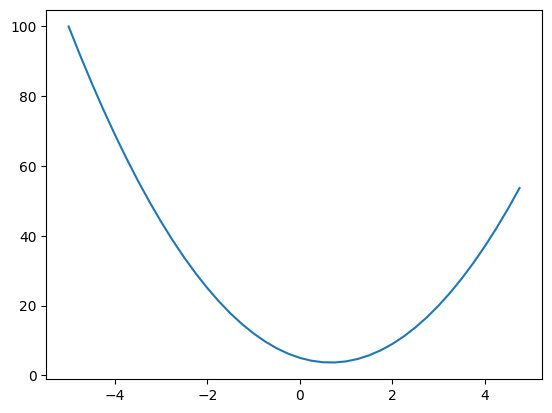

In [13]:
xs=np.arange(-5,5,0.25)
ys=f(xs)
plt.plot(xs,ys)


### concept of the derviaties here how twiking the tiny value may change in the slope

In [14]:
h=0.0001
x=3.00
der=(f(x+h)-f(x))/h

In [15]:
# input
a=2.0
b=-3.0
c=10.0
h=0.001
# equation
d1=a*b+c
a+=h
d2=a*b+c
print("d1",d1)
print("d2",d2)

d1 4.0
d2 3.997


### understading with the class value

In [18]:
import math

class Value:
  def __init__(self,data,_children=(),_op='',label=''):
    self.data=data
    self._prev=set(_children) # _children is clearer for previous nodes (inputs to this operation)
    self._op=_op # The operation that created this node
    self.label=label
    self.grad=0.0
    # This stores the local gradient function for this node, specific to the operation that created it.
    # It gets set by the operations (+, *, tanh) that create this node.
    self._backward_fn=lambda:None

  def __repr__(self):
    return f"Value(data={self.data})"

  def __add__(self,other):
    other=other if isinstance(other,Value) else Value(other)
    out = Value(self.data+other.data,(self,other),'+',label='add')

    def _backward_fn(): # Define the specific backprop logic for addition
      self.grad+=1.0*out.grad
      other.grad+=1.0*out.grad
    out._backward_fn=_backward_fn # Assign this specific backprop logic to the 'out' Value's _backward_fn method.
    return out

  def __mul__(self,other):
    other=other if isinstance(other,Value) else Value(other)
    out = Value(self.data*other.data,(self,other),'*',label='multi')

    def _backward_fn(): # Define the specific backprop logic for multiplication
      # dL/da = dL/dout * dout/da = out.grad * other.data
      self.grad+=other.data*out.grad
      # dL/db = dL/dout * dout/db = out.grad * self.data
      other.grad+=self.data*out.grad
    out._backward_fn=_backward_fn # Assign this specific backprop logic to the 'out' Value's _backward_fn method.
    return out
  # for removing the mul prob
  def __rmul__(self,other):
      return self * other
  # for removing the div prob
  def __truediv__(self,other):
    return other*(self**-1)
  # for removing the neg prob
  def __neg__(self):
    return self*-1
  # for removing the substraction problem
  def __sub__(self,other):
    return self - other
  # for removing the addition prob
  def __radd__(self,other):
    return self+other
  # for removing the power
  def __pow__(self,other):
    assert isinstance(other,(int,float)),"only supporting int/float powers for now"
    out=Value(self.data**other,(self,),f'**{other}',label=f'{self.label}**{other}')
    def _backward_fn():
      self.grad+=other*(self.data**(other-1))*out.grad
    out._backward_fn=_backward_fn
    return out



  def  tanh(self):

    x = self.data
    t=(math.exp(2*x)-1)/(math.exp(2*x)+1) # Calculate tanh(x)
    out = Value(t,(self,),'tanh',label='tanh')

    def _backward_fn(): # Define the specific backprop logic for tanh
      # dL/dx = dL/dout * dout/dx = out.grad * (1 - tanh(x)^2)
      self.grad += (1 - t**2) * out.grad
    out._backward_fn = _backward_fn # Assign this specific backprop logic to the 'out' Value's _backward_fn method.
    return out
  def exp(self):
    x=self.data
    out=Value(math.exp(x),(self,),'exp',label='exp')
    # as we know that d/dx e*x=e*x   , d/dx e*u=e*u du/dx
    def _backward_fn():
      self.grad+=out.data*out.grad
    out._backward_fn=_backward_fn
    return out
  def build_topo(root):

    topo = []
    visited = set()

    def dfs(node):
        if node not in visited:
            visited.add(node)
            for child in node._prev:
                dfs(child)
            topo.append(node)

    dfs(root)

    # --- Code to perform backpropagation and compute gradients ---
    # 1. Reset all gradients in the graph to 0.0
    for node in topo:
        node.grad = 0.0

    # 2. Set the gradient of the output (root) node to 1.0
    root.grad = 1.0

    # 3. Iterate through the graph in reverse topological order and compute gradients
    for node in reversed(topo):
        node._backward_fn()
    # --- End of gradient computation code ---


In [153]:
t=Value(5)
s=Value(4)
t*4
t**4.4

Value(data=1189.7837116974247)

In [42]:
from graphviz import Digraph

def trace(root):
  # builds a set of all nodes and edges in a graph
  nodes, edges = set(), set()
  def build(v):
    if v not in nodes:
      nodes.add(v)
      for child in v.childern:
        edges.add((child, v))
        build(child)
  build(root)
  return nodes, edges

def draw_dot(root):
  dot = Digraph(format='svg', graph_attr={'rankdir': 'LR'}) # LR = left to right

  nodes, edges = trace(root)
  for n in nodes:
    uid = str(id(n))
    # for any value in the graph, create a rectangular ('record') node for it
    dot.node(name = uid, label = "{ %s | data %.4f | grad %.4f}" % (n.label, n.data,n.grad), shape='record')
    if n.ope:
      # if this value is a result of some operation, create an op node for it
      dot.node(name = uid + n.ope, label = n.ope)
      # and connect this node to it
      dot.edge(uid + n.ope, uid)

  for n1, n2 in edges:
    # connect n1 to the op node of n2
    dot.edge(str(id(n1)), str(id(n2)) + n2.ope)

  return dot


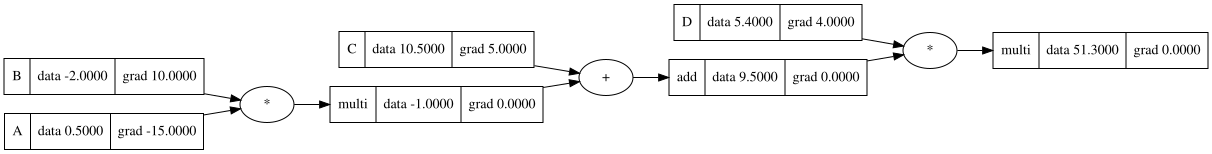

In [163]:
draw_dot(g)

In [18]:
# the thing that we have to take care in this is that we have to make any change make sure the object value inside best
def lol():
  a=Value(2.0,label="A")
  b=Value(-3.0,label='B')
  c=Value(10.0,label='C')
  d=Value(5.0,label='D')
  e=a*b
  f=e+c
  g=f*d
  g1=g.data
  h=0.001
  a=Value(2.0,label="A")
  b=Value(-3.0 + h,label='B') # Fixed: Incorporate 'h' directly into 'b'
  c=Value(10.0,label='C')
  d=Value(5.0,label='D')
  e=a*b
  f=e+c
  g=f*d
  g2=g.data
  print(g1-g2)
lol()

-0.00999999999999801


In [95]:
def lol():
  a=Value(2.0,label="A")
  b=Value(-3.0,label='B')
  c=Value(10.0,label='C')
  d=Value(5.0,label='D')
  e=a*b
  f=e+c
  g=f*d
  g1=g.data
  h=0.001
  a=Value(2.0,label="A")
  b=Value(-3.0 ,label='B')
  c=Value(10.0,label='C')
  d=Value(5.0,label='D')
  e=a*b
  f=e+c
  g=f*d
  g2=g.data+h
  de=((g2-g1))/h
  print(de)
lol()

1.0000000000012221


In [22]:
g.grad=1.00

NameError: name 'g' is not defined

####L=d*f
####dl/dd=?,f
####f(x+h)-f(x)/h
####(d+h)*f-d*f/h
####h*f/h
####f




In [23]:
f.grad=5
d.grad=4

NameError: name 'd' is not defined

In [25]:
# derivative check of f,d
def lol():
  h=0.001
  a=Value(2.0,label="A")
  b=Value(-3.0,label='B')
  c=Value(10.0,label='C')
  d=Value(5.0,label='D')
  e=a*b
  f=e+c
  g=f*d
  g1=g.data
  a=Value(2.0,label="A")
  b=Value(-3.0 ,label='B')
  c=Value(10.0,label='C')
  d=Value(5.0+h,label='D')
  e=a*b
  f=e+c
  g=f*d
  g2=g.data
  de=((g2-g1)/h)
  print(de)
lol()

4.000000000001336


### calculating the gradient of the c and the mutli and here we apply the chain rule

In [26]:
# derivative check of f,d
def lol():
  h=0.001
  a=Value(2.0,label="A")
  b=Value(-3.0,label='B')
  c=Value(10.0,label='C')
  d=Value(5.0,label='D')
  e=a*b
  f=e+c
  g=f*d
  g1=g.data
  a=Value(2.0,label="A")
  b=Value(-3.0 ,label='B')
  #c=Value(10.0+h,label='C')
  c=Value(10.0,label='C')
  d=Value(5.0,label='D')
  e=a*b
  e.data+=h
  f=e+c
  g=f*d
  g2=g.data
  de=((g2-g1)/h)
  print(de)
lol()

5.000000000002558


In [27]:
e.grad=5.00
c.grad=5.00

NameError: name 'e' is not defined

### calculating the gradient of the a,b with respect to L

In [28]:
# derivative check of f,d
def lol():
  h=0.001
  a=Value(2.0,label="A")
  b=Value(-3.0,label='B')
  c=Value(10.0,label='C')
  d=Value(5.0,label='D')
  e=a*b
  f=e+c
  g=f*d
  g1=g.data
  #a=Value(2.0+h,label="A")
  a=Value(2.0,label="A")
  #b=Value(-3.0 ,label='B')
  b=Value(-3.0+h ,label='B')
  #c=Value(10.0+h,label='C')
  c=Value(10.0,label='C')
  d=Value(5.0,label='D')
  e=a*b
  #e.data+=h
  f=e+c
  g=f*d
  g2=g.data
  de=((g2-g1)/h)
  print(de)
lol()

9.99999999999801


In [29]:
a.grad=-15.00
b.grad=10.00

AttributeError: 'float' object has no attribute 'grad'

### making the improvement in it


In [30]:
# Re-initialize Value objects with their initial data and assigned gradients
# These initial data values are taken from cell 0fecCNDufg-o.
# The grad values are taken from cells 2WOI_8oeo5ni, ywEZoeiyKfeI, and inferred for c.grad.

# Re-instantiate 'a'
a = Value(2.0, label="A")
a.grad = -15.0 # From cell 2WOI_8oeo5ni

# Re-instantiate 'b'
b = Value(-3.0, label="B")
b.grad = 10.0 # From cell 2WOI_8oeo5ni

# Re-instantiate 'c'
c = Value(10.0, label="C")
# Infer c.grad from f.grad=5 and f=e+c. If f.grad=5, and df/dc=1, then c.grad=5.
c.grad = 5.0

# Re-instantiate 'd'
d = Value(5.0, label="D")
d.grad = 4.0 # From cell ywEZoeiyKfeI

# Learning rate
alpha = 0.1

# Apply gradient updates
a.data += alpha * a.grad
b.data += alpha * b.grad
c.data += alpha * c.grad # Corrected: use c.grad, not b.grad
d.data += alpha * d.grad

# Recalculate e, f, g with updated data values
e = a * b
f = e + c
g = f * d
print(g)

Value(data=51.300000000000004)


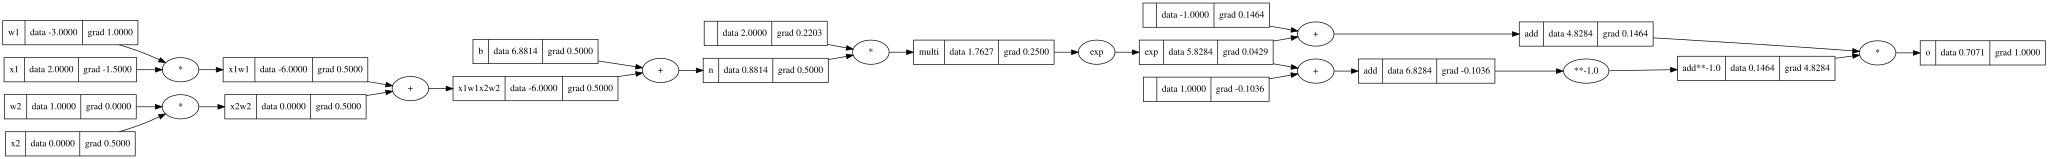

In [162]:
# the value of the x inp
x1=Value(2.0,label="x1")
x2=Value(0.0,label="x2")
# the value of the weight w
w1=Value(-3.0,label="w1")
w2=Value(1.0,label="w2")
# the value of the bias
b=Value(6.8813735870195432,label="b")
#calculation
x1w1=x1*w1
x2w2=x2*w2
x1w1.label="x1w1"
x2w2.label="x2w2"
x1w1x2w2=x1w1+x2w2
x1w1x2w2.label="x1w1x2w2"
n=x1w1x2w2+b
n.label="n"
e=(n*2).exp()

# Corrected calculation for o to avoid recursive __sub__ and incorrect __truediv__
# (e - 1) is rewritten as e + (-1)
# (X / Y) is rewritten as X * (Y ** -1)
numerator = e + Value(-1.0) # Explicitly create Value for -1
denominator = e + Value(1.0)  # Explicitly create Value for 1
o = numerator * (denominator ** -1.0) # Corrected: exponent is now a float
o.label="o"

# Call build_topo to perform backpropagation, as o.backward() does not exist.
build_topo(o)
draw_dot(o)

### without the hyperbolic function

In [41]:
from graphviz import Digraph

# Redefine trace with the correct attribute
def trace(root):
  # builds a set of all nodes and edges in a graph
  nodes, edges = set(), set()
  def build(v):
    if v not in nodes:
      nodes.add(v)
      # Fix: Use v._prev instead of v.childern
      for child in v._prev:
        edges.add((child, v))
        build(child)
  build(root)
  return nodes, edges

# Redefine draw_dot to use the corrected trace and _op attribute
def draw_dot(root):
  dot = Digraph(format='svg', graph_attr={'rankdir': 'LR'}) # LR = left to right

  nodes, edges = trace(root)
  for n in nodes:
    uid = str(id(n))
    # for any value in the graph, create a rectangular ('record') node for it
    # Fix: Use n._op instead of n.ope
    dot.node(name = uid, label = "{ %s | data %.4f | grad %.4f}" % (n.label, n.data,n.grad), shape='record')
    if n._op: # Changed from n.ope to n._op
      # if this value is a result of some operation, create an op node for it
      dot.node(name = uid + n._op, label = n._op) # Changed from n.ope to n._op
      # and connect this node to it
      dot.edge(uid + n._op, uid) # Changed from n.ope to n._op

  for n1, n2 in edges:
    # connect n1 to the op node of n2
    # Fix: Use n2._op instead of n2.ope
    dot.edge(str(id(n1)), str(id(n2)) + n2._op) # Changed from n2.ope to n2._op

  return dot

draw_dot(o)

AttributeError: 'Tensor' object has no attribute '_prev'

### with hyperbolic function

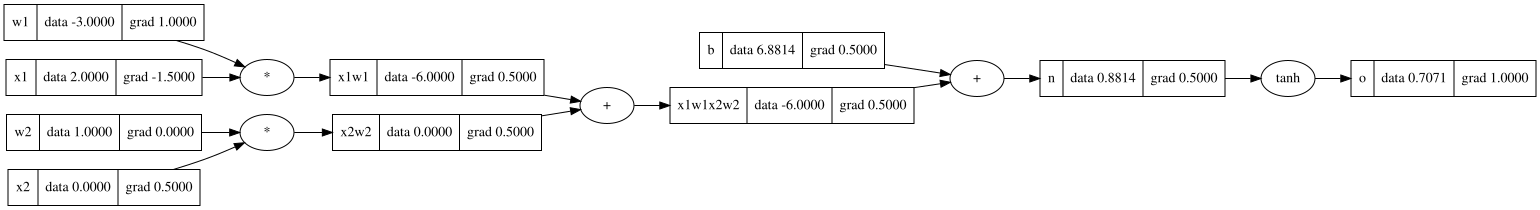

In [104]:
draw_dot(o)

In [103]:
build_topo(o)


### automatic backpropagation

In [73]:
o.grad=1.00

In [35]:
o._backward_fn()

In [36]:
n._backward_fn()

In [37]:
x1w1x2w2._backward_fn()

In [38]:
x1w1._backward_fn()
x2w2._backward_fn()

###back propagation here
####derviative of tanh=1-tanh**2

### manual back propagation

In [39]:
o.grad=1.00


In [40]:
#1-tanh*2
o.data
n.grad=1-o.data**2


In [41]:
x1w1x2w2.grad=n.grad
b.grad=n.grad

In [42]:
x1w1.grad=x1w1x2w2.grad
x2w2.grad=x1w1x2w2.grad

In [43]:
x1.grad=w1.data*x1w1.grad
w1.grad=x1.data*x1w1.grad

In [44]:
x2.grad=w2.data*x2w2.grad
w2.grad=x2.data*x2w2.grad

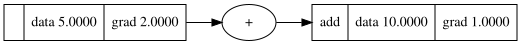

In [112]:
a=Value(5)
b=a+a
draw_dot(b)
build_topo(b)
draw_dot(b)

In [4]:
!pip install torch

### implementation in  the pytorch


In [10]:
import torch
x1 = torch.Tensor([2.0]).double()                ; x1.requires_grad = True
x2 = torch.Tensor([0.0]).double()                ; x2.requires_grad = True
w1 = torch.Tensor([-3.0]).double()               ; w1.requires_grad = True
w2 = torch.Tensor([1.0]).double()                ; w2.requires_grad = True
b = torch.Tensor([6.8813735870195432]).double()  ; b.requires_grad = True
n = x1*w1 + x2*w2 + b
o = torch.tanh(n)

print(o.data.item())
o.backward()

print('---')
print('x2', x2.grad.item())
print('w2', w2.grad.item())
print('x1', x1.grad.item())
print('w1', w1.grad.item())

0.7071066904050358
---
x2 0.5000001283844369
w2 0.0
x1 -1.5000003851533106
w1 1.0000002567688737


In [11]:
import torch

### creating the neural network here

In [67]:
import random
class Neuron:
  def __init__(self, nin):
    self.w = [Value(random.uniform(-1,1)) for _ in range(nin)]
    self.b = Value(random.uniform(-1,1))
  def __call__(self,x):
    #print(list(zip(self.w,x)))
    act=sum((wi*xi for wi,xi in zip(self.w,x)),self.b)
    out=act.tanh()
    return out
class Layer:
  def __init__(self,nin,nout):
    self.neurons=[Neuron(nin) for _ in range(nout)]
  def __call__(self,x):
    outs=[n(x) for n in self.neurons]
    return outs[0] if len(outs)==1 else outs
class MLP:
   def __init__(self, nin, nouts):
    sz = [nin] + nouts
    self.layers = [Layer(sz[i], sz[i+1]) for i in range(len(nouts))]

   def __call__(self, x):
    for layer in self.layers:
      x = layer(x)
    return x

x=[1.0,3.0,4.0]
n=MLP(3,[4,4,1])
n(x)

Value(data=0.8698937041623874)

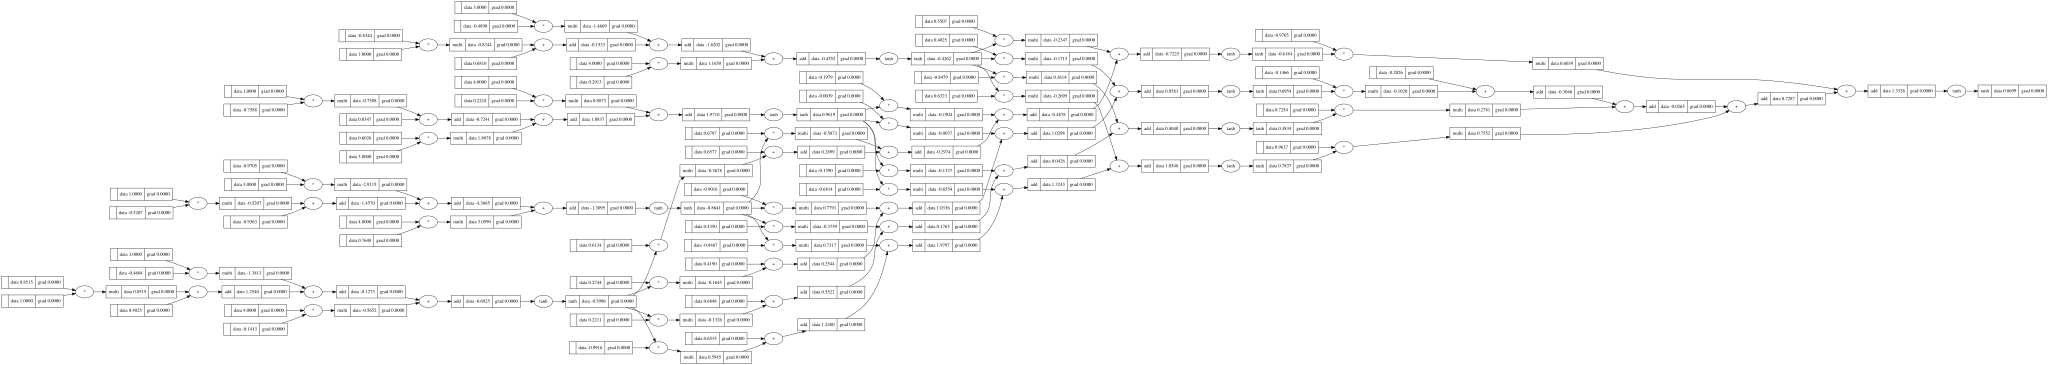

In [68]:
from graphviz import Digraph

def trace(root):
  # builds a set of all nodes and edges in a graph
  nodes, edges = set(), set()
  def build(v):
    if v not in nodes:
      nodes.add(v)
      # Fix: Use v._prev instead of v.childern
      for child in v._prev:
        edges.add((child, v))
        build(child)
  build(root)
  return nodes, edges

def draw_dot(root):
  dot = Digraph(format='svg', graph_attr={'rankdir': 'LR'}) # LR = left to right

  nodes, edges = trace(root)
  for n in nodes:
    uid = str(id(n))
    # for any value in the graph, create a rectangular ('record') node for it
    # Fix: Use n._op instead of n.ope
    dot.node(name = uid, label = "{ %s | data %.4f | grad %.4f}" % (n.label, n.data,n.grad), shape='record')
    if n._op: # Changed from n.ope to n._op
      # if this value is a result of some operation, create an op node for it
      dot.node(name = uid + n._op, label = n._op) # Changed from n.ope to n._op
      # and connect this node to it
      dot.edge(uid + n._op, uid) # Changed from n.ope to n._op

  for n1, n2 in edges:
    # connect n1 to the op node of n2
    # Fix: Use n2._op instead of n2.ope
    dot.edge(str(id(n1)), str(id(n2)) + n2._op) # Changed from n2.ope to n2._op

  return dot

draw_dot(n(x))

In [53]:
xs = [
  [2.0, 3.0, -1.0],
  [3.0, -1.0, 0.5],
  [0.5, 1.0, 1.0],
  [1.0, 1.0, -1.0],
]
ys = [1.0, -1.0, -1.0, 1.0] # desired targets
y_pred=[n(x) for x in xs]
y_pred

[Value(data=-0.9501850877559966),
 Value(data=-0.8781151941462605),
 Value(data=-0.9130170816704068),
 Value(data=-0.9670411651315123)]

### removing the problem of the recursion error in the sub method in the value class

In [58]:
# Patch the __sub__ method of the Value class to avoid recursion.
# Assuming Value class is already defined in the global scope.

def _correct_sub_Value(self, other):
    other = other if isinstance(other, Value) else Value(other)
    return self + (-other)

# Patch the __truediv__ method as it was also noted as incorrect in earlier context
def _correct_truediv_Value(self, other):
    other = other if isinstance(other, Value) else Value(other)
    return self * (other**-1)

Value.__sub__ = _correct_sub_Value
Value.__truediv__ = _correct_truediv_Value


### generating the loss function here

In [64]:

# Original loss calculation
loss=sum(((yout-ygt)**2) for ygt,yout in zip(ys,y_pred))
loss

Value(data=7.694894755806938)

In [77]:
n.layers[1].neurons[0].w[0].grad

0.0

In [69]:
loss.build_topo()

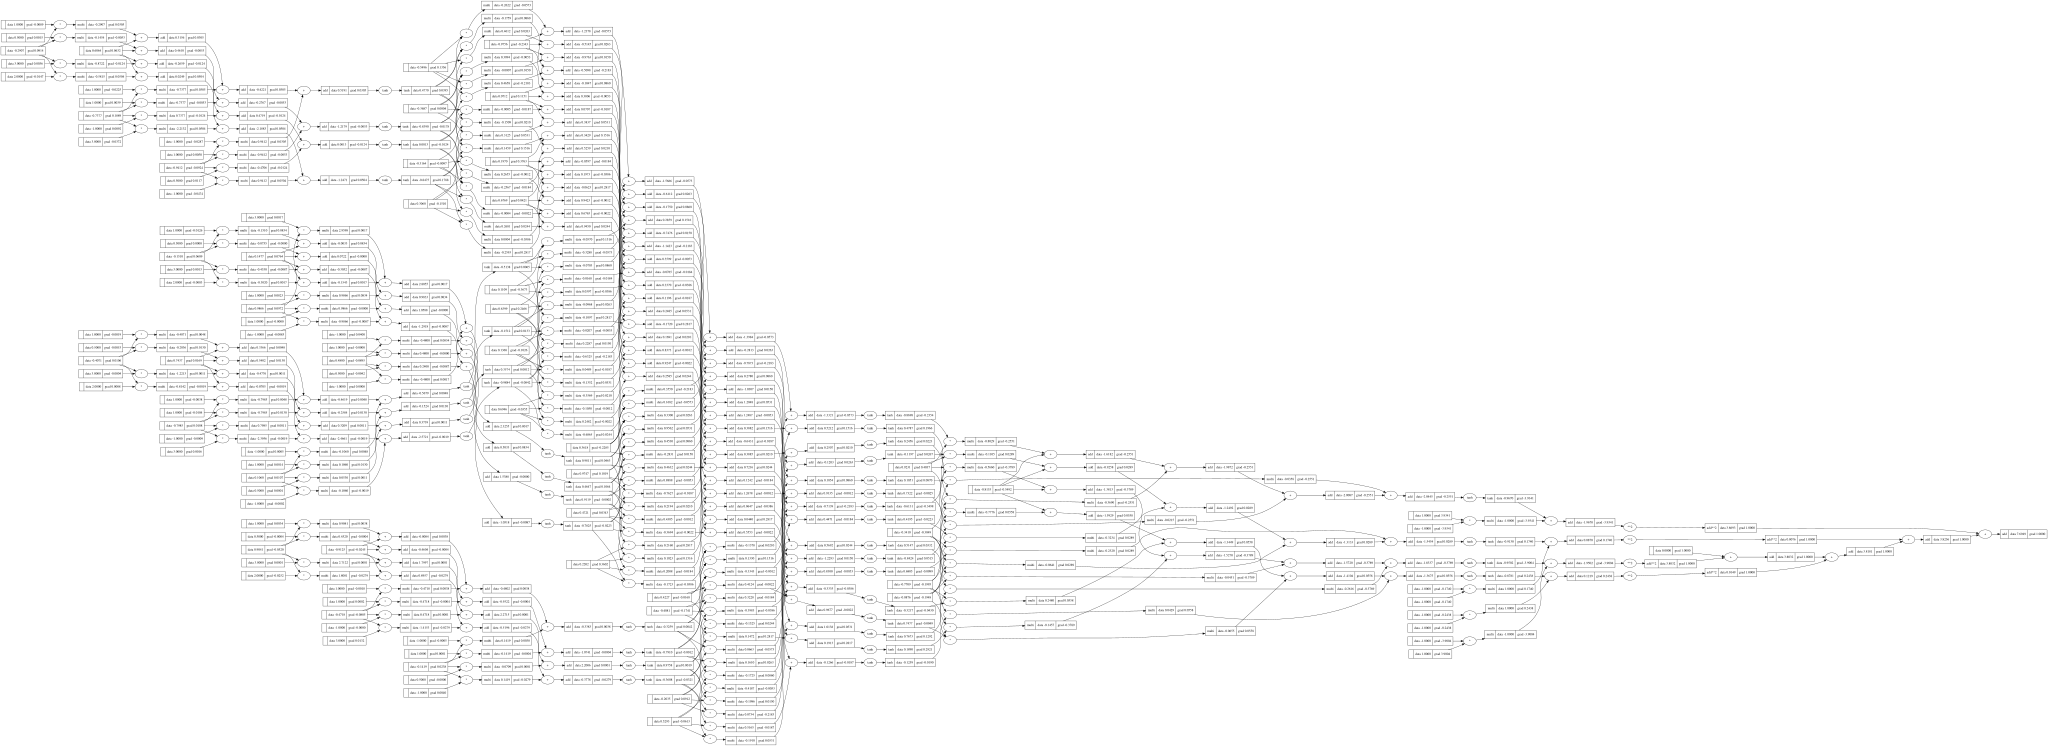

In [70]:
draw_dot(loss)